<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>From Scratch MLP - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [192]:
# Install Requirements Using Pip
%pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [193]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [194]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [195]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

### Check for Internet Access

In [196]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [197]:
internet_required = False

In [198]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load and Explore the Dataset

From: https://archive.ics.uci.edu/dataset/222/bank+marketing

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to assess if the product (bank term deposit) would be subscribed or not ('yes' or 'no).

[This dataset is] bank-full.csv with all examples and 17 inputs, ordered by date (there is also an older version of this dataset available with fewer inputs). 

The classification goal is to predict if the client will subscribe (yes/no) a term deposit (variable y).

|Variable Name	|Role	|Type	|Demographic|	Description|	Units|	Missing Values|
|---|---|---|---|---|---|---|
|age|	Feature|	Integer|	Age|	|	|	no|
|job|	Feature	|Categorical	|Occupation	|type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')||		no|
|marital	|Feature|	Categorical|	Marital Status|	marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)||		no|
|education	|Feature|	Categorical	|Education Level|	(categorical: 'primary', 'secondary', 'tertiary', 'unknown')||		no|
|default	|Feature|	Binary		||has credit in default?||		no|
|balance	|Feature|	Integer		||average yearly balance|	euros	|no|
|housing	|Feature|	Binary		||has housing loan?||		no|
|loan	|Feature|	Binary	||	has personal loan?||		no|
|contact	|Feature|	Categorical	||	contact communication type (categorical: 'cellular','telephone')||		yes|
|day	|Feature|	Integer	||	last contact day of the month||		unknown|
|month	|Feature|	Date	||	last contact month of the year||		unknown|
|duration	|Feature|	Integer	||	last contact duration, in seconds (numeric)||		unknown|
|campaign	|Feature|	Integer	||	number of contacts performed during this campaign and for this client (numeric, includes last contact)||		unknown|
|pdays	|Feature|	Integer	||number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)||		unknown|
|previous	|Feature|	Integer	||number of contacts performed before this campaign and for this client (numeric)||		unknown|
|poutcome	|Feature|	Categorical	|| outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")||		unknown|



In [199]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('https://datascience.daemonchild.com/year3/dat6002/bank-full.csv', delimiter=';')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank-full.csv', delimiter=';')

Initial exporation of the shape and composition of the dataset.

In [200]:
print (df.columns)
print ("")
print (df.shape)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

(45211, 17)


In [201]:
df.sample(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
25383,45,technician,divorced,secondary,no,-14,no,no,cellular,18,nov,39,2,127,3,failure,no
4477,32,technician,single,secondary,no,1698,yes,no,unknown,20,may,115,1,-1,0,unknown,no
31584,33,admin.,married,tertiary,no,1636,yes,yes,cellular,3,apr,105,1,136,1,failure,no
12082,39,admin.,divorced,secondary,no,1022,yes,no,unknown,20,jun,20,3,-1,0,unknown,no
15996,51,admin.,married,secondary,no,194,no,yes,cellular,22,jul,71,2,-1,0,unknown,no


In [202]:
df.dropna(inplace=True)
df.shape

(45211, 17)

In [203]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [204]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Define chart colour palette

In [205]:
COLOUR_TEAL = '#31688E'
COLOUR_ORANGE = '#CF4446'
COLOUR_GREEN = '#35B779'
COLOUR_YELLOW = '#FDE725'


palette=[COLOUR_TEAL, COLOUR_ORANGE, COLOUR_GREEN, COLOUR_YELLOW]

# Set global parameters
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[COLOUR_TEAL, COLOUR_ORANGE])
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['grid.alpha'] = 0.3

### Target Variable Y

Exploring the target data variable 'y' shows that there is bias in the dataset. The majority of people did not deposit funds.<br>
The success rate is actually very good for a cold calling telephone marketing campaign, although the dataset is quite old (from May 2008 to November 2010).

"The average cold-calling success rate in 2025 is 2.3%, almost half of what it was in 2024 (4.82%)."<br>
From https://www.cognism.com/blog/cold-calling-success-rates

This will likely cause some issues for the neural network because the weights will tend to shift to favour negative responses; there are not many instances of positive responses to learn from.

In [206]:
df.sample(5)['y']

29643     no
21565     no
21533     no
31526    yes
43017    yes
Name: y, dtype: str

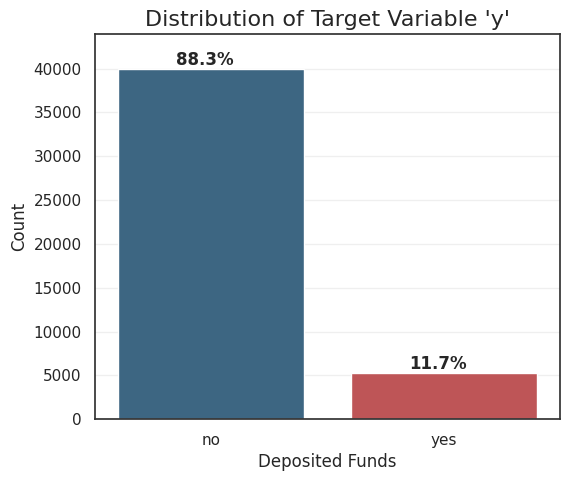

In [207]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='y', data=df, palette=palette)

# Calculate total for percentages
total = len(df['y'])

# Add labels to each bar
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%' 
    x = p.get_x() + p.get_width() / 2 - 0.15          
    y = p.get_height() + (total * 0.01)               
    ax.annotate(percentage, (x, y), size = 12, weight = 'bold')

plt.title("Distribution of Target Variable 'y'", fontsize=16)
plt.xlabel("Deposited Funds", fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.ylim(0, df['y'].value_counts().max() * 1.1)

plt.savefig('graphs/target_y_count_plot.png', bbox_inches='tight', dpi=300)
plt.show()

The target feature will be binary encoded later on in this notebook. I will leave it as yes/no for now to allow futher analysis in this state.

## Exploring Numeric Features

### Age

The age feature is likely to contain outliers. <br>
I intend to use Min-Max scaling to scale most of the features as a floating point number between 0.0 to 1.0.<br>

$ x_{scaled} = \frac{x - min(x)}{max(x)-min(x)}$

However, Min-Max scaling is sensitive to outliers. If there were a single 95-year-old outlier and a single 18-year-old oulier, Min-Max scaling will set 95 to 1.0 and 18 to 0.0. There are very few people in the dataset at this ag so they stretch the scale, making the differences between a 30-year-old and a 40-year-old look much smaller to the MLP.

Therefore, I would like to determine the potential effect of the age range on the input to the MLP. I have used a violin plot to confirm where these outliers lie.

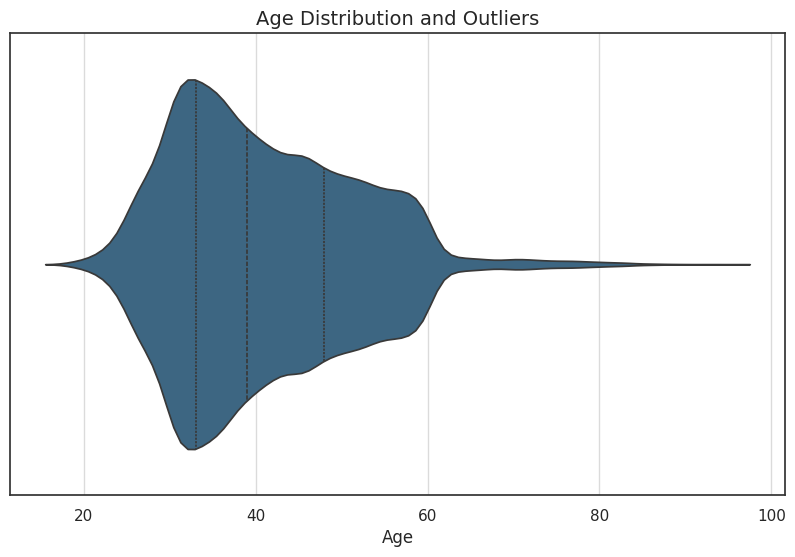

Min Age in Dataset: 18
Max Age in Dataset: 95


In [208]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['age'], color=palette[0], inner='quartile')

plt.title('Age Distribution and Outliers', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.7)
plt.savefig('graphs/age_violin_plot.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Min Age in Dataset: {df['age'].min()}")
print(f"Max Age in Dataset: {df['age'].max()}")

The plot shows a massive bulge between 30 and 45. This is expected and is the target audience for the bank's marketing department.
The tail shows the older outliers who are people over 65-70 years old.

I will need to use a suitable scaling mechanism for these features.

### Balance

Like age, the bank balance feature is very likely to contain outliers.

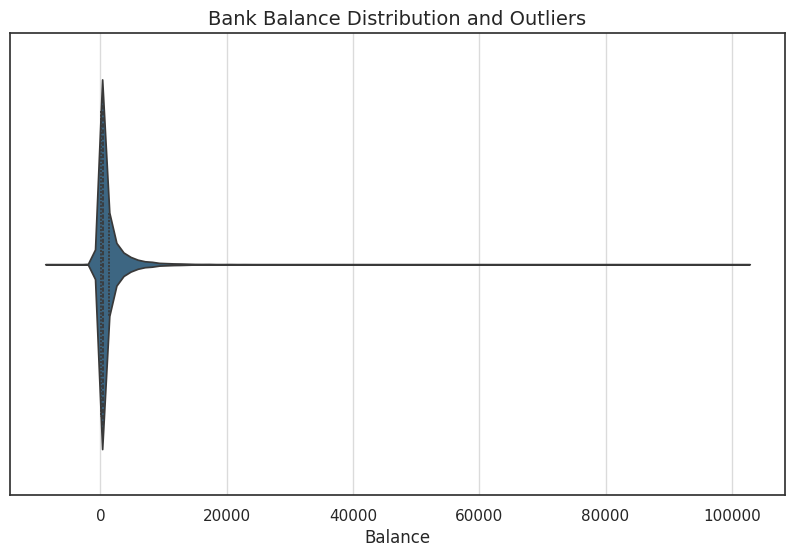

Min Balance in Dataset: -8019
Max Balance in Dataset: 102127


In [209]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['balance'], color=palette[0], inner='quartile')

plt.title('Bank Balance Distribution and Outliers', fontsize=14)
plt.xlabel('Balance', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.7)
plt.savefig('graphs/balance_violin_plot.png', bbox_inches='tight', dpi=300)
plt.show()


print(f"Min Balance in Dataset: {df['balance'].min()}")
print(f"Max Balance in Dataset: {df['balance'].max()}")

As expected, there is a massive variance in the balances of those called by the banks marketeers.

### Campaign

This is the number of times that a person was called during the merketing campaign.<br>
From the initial analysis using df.describe, there also appears to be some outliers in the campaign feature. 

While it's somewhat excessive, the maximum number of calls made to a person was 63!<br>
There are a fair few outliers, so thsi column should also be scaled using a different mechanism.

In [210]:
# Filter the dataframe to > 30 calls, then count
over_30_count = df[df['campaign'] > 30]['campaign'].value_counts().sort_index()

print(over_30_count)

campaign
31    12
32     9
33     6
34     5
35     4
36     4
37     2
38     3
39     1
41     2
43     3
44     1
46     1
50     2
51     1
55     1
58     1
63     1
Name: count, dtype: int64


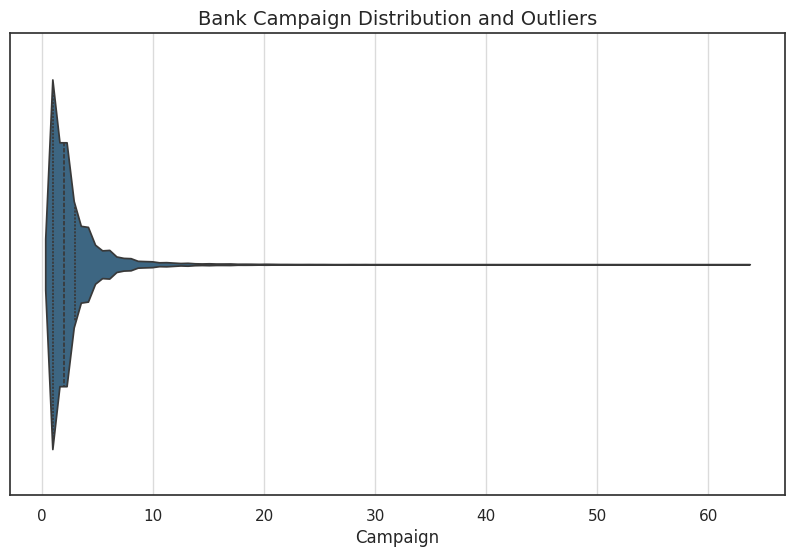

Min Campaign in Dataset: 1
Max Campaign in Dataset: 63


In [211]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['campaign'], color=palette[0], inner='quartile')

plt.title('Bank Campaign Distribution and Outliers', fontsize=14)
plt.xlabel('Campaign', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.7)
plt.savefig('graphs/campaign_violin_plot.png', bbox_inches='tight', dpi=300)
plt.show()


print(f"Min Campaign in Dataset: {df['campaign'].min()}")
print(f"Max Campaign in Dataset: {df['campaign'].max()}")

### Number of Previous Contacts

In [212]:
# Filter the dataframe to > 30 calls, then count
over_30_count = df[df['previous'] > 30]['previous'].value_counts().sort_index()

print(over_30_count)

previous
32     1
35     1
37     2
38     2
40     1
41     1
51     1
55     1
58     1
275    1
Name: count, dtype: int64


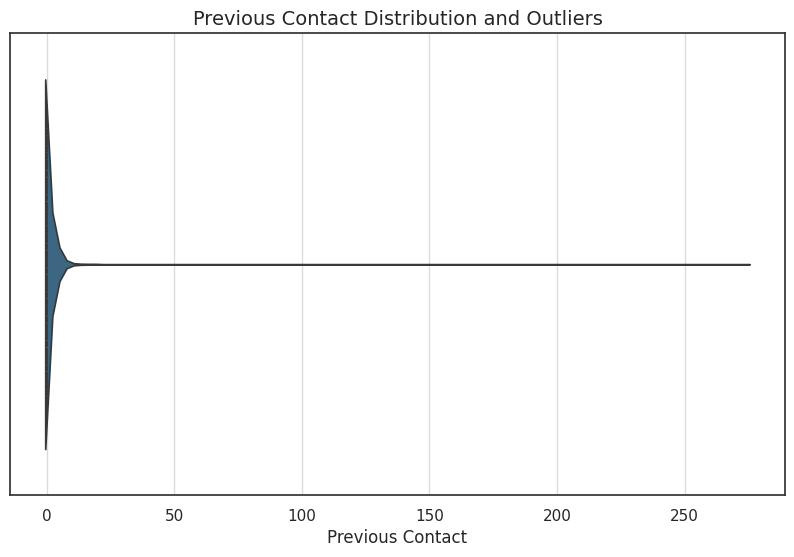

Min Previous Contact in Dataset: 0
Max Previous Contact in Dataset: 275


In [213]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['previous'], color=palette[0], inner='quartile')

plt.title('Previous Contact Distribution and Outliers', fontsize=14)
plt.xlabel('Previous Contact', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.7)
plt.savefig('graphs/previous_violin_plot.png', bbox_inches='tight', dpi=300)
plt.show()


print(f"Min Previous Contact in Dataset: {df['previous'].min()}")
print(f"Max Previous Contact in Dataset: {df['previous'].max()}")

### Pdays

The pdays feature requires special consideration. 

People who have never been called before are represented as -1.<br>
The rest of the data shows how long it has been since they were contacted previously.

It will likely show a bi-modal distribution, consisting of a dominant peak at -1 and a secondary distribution of values. These two groups represent different  behaviours. Therefore, applying a simple linear scaler to this data would not accurately capture the difference between these distinct groups. There would be a loss of meaning.

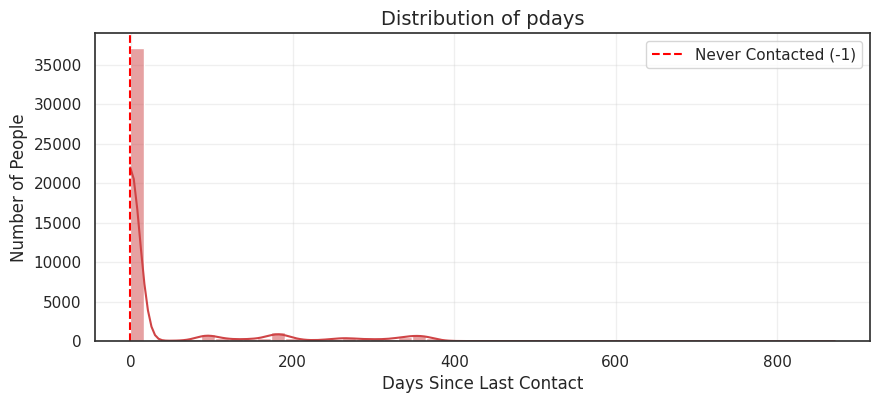

In [214]:
plt.figure(figsize=(10, 4))

sns.histplot(df['pdays'], bins=50, kde=True, color=palette[1])

plt.axvline(x=-1, color='red', linestyle='--', label='Never Contacted (-1)')
plt.title('Distribution of pdays', fontsize=14)
plt.xlabel('Days Since Last Contact', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('graphs/pdays_histogram.png', bbox_inches='tight', dpi=300)
plt.show()


It is difficult to see the distribution of the positive values, so I have filtered out the uncontacted people:

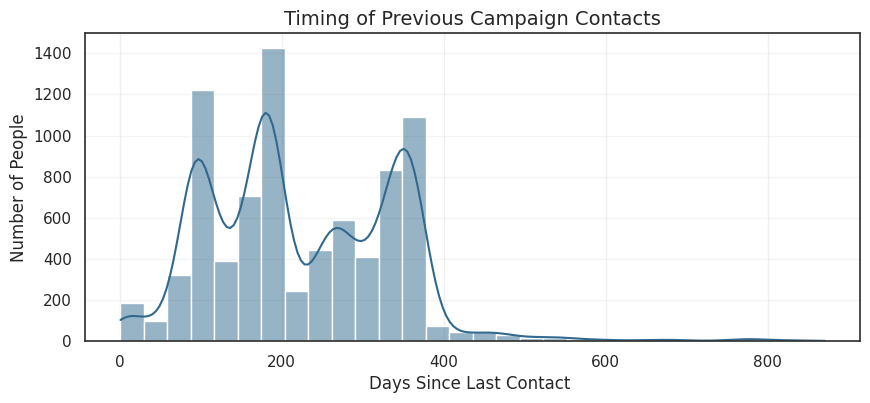

Average follow-up time: 224.58 days
Median follow-up time: 194.00 days


In [215]:
# Create a filtered series without the -1 values
contacted_only = df[(df['pdays'] != -1)] ['pdays']

# Plot the distribution
plt.figure(figsize=(10, 4))
sns.histplot(contacted_only, bins=30, kde=True, color=palette[0])

plt.title('Timing of Previous Campaign Contacts', fontsize=14)
plt.xlabel('Days Since Last Contact ', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.savefig('graphs/pdays_contacted_only_histogram.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Average follow-up time: {contacted_only.mean():.2f} days")
print(f"Median follow-up time: {contacted_only.median():.2f} days")

The filtered pdays distribution is actually multi-modal, exhibiting several local maxima. These periodic peaks likely correspond to follow-up schedules such as 7-days, 14-days, 30-days etc. The feature 'time since last contact' is not a simple linear relationship, but a much more complicated feature where specific points in time are more significant than others. 

This feature will need to be treated differently again. It would be simplest to drop it from the model, however I feel that there is possibly useful meaning in including it. Afterall, who likes to be hassled by marketing phone calls? Does this not potentially imply some negative impact?

There are peaks at approximately 100, 180, 275 and 365 days. This suggests a re-engagement strategy based on quarterly cycles.<br>
To ensure the MLP captures these specific windows of opportunity, I will use a binning strategy based around these values:

In [216]:
def bins_for_pdays(val):
    if val == -1: return 0     # Never contacted
    if val <= 30: return 1     # Short term
    if val <= 150: return 2    # Captures 100 day peak
    if val <= 250: return 3    # Captures 180 day peak
    return 4                   # Longer term

df['pdays_binned'] = df['pdays'].apply(bins_for_pdays)

### Month

The month feature can be directly converted into a numeric field while maintaining meaning.<br>
There is a mathematical flaw in that the gap between December and January is '11', but in reality is only a single month.

If the MLP fails to learn sufficiently well, then this feature could be handled differently by representing the cyclical nature of the data using a sine function. However, even simple represented as values from 1 to 12 will be better than one hot encoding which woudl result in 12 new binary columns (and therefore input neurons).

In [217]:
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# Apply the map to the 'month' column
df['month_numeric'] = df['month'].map(month_map)

# Check the result
print(df['month_numeric'].value_counts().sort_index())

month_numeric
1      1403
2      2649
3       477
4      2932
5     13766
6      5341
7      6895
8      6247
9       579
10      738
11     3970
12      214
Name: count, dtype: int64


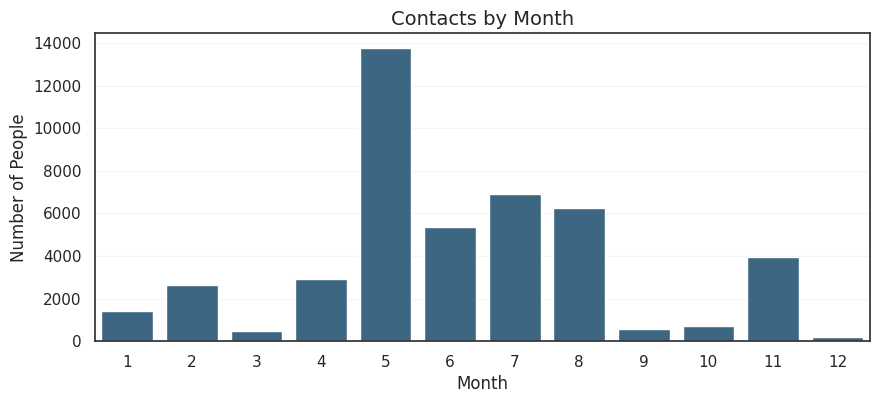

In [218]:
# Plot the distribution
plt.figure(figsize=(10, 4))
sns.barplot(x='month_numeric', y='count', data=df.groupby('month_numeric').size().reset_index(name='count'), color=palette[0])

plt.title('Contacts by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.savefig('graphs/month_numeric_histogram.png', bbox_inches='tight', dpi=300)
plt.show()

### Education
Education follows a pattern of progression from none through university education.<br>
The education feature is slightly challenging however, as it features an 'unknown' value. 

I intend to create a dictionary to use as a map to a score value for each of these levels.<br>
It is necessary to determine whether the 'unknowns' should be treated as a low, medium or high score in relation to the distribution of the rest of the cohort.<br>

One alternative is to give the 'unknown' value a score that matches the mode or the median. <br>
It is also possible that the best approach may be to One Hot Encode this feature.

In [219]:
df.education.value_counts(normalize=True).round(2)*100

education
secondary    51.0
tertiary     29.0
primary      15.0
unknown       4.0
Name: proportion, dtype: float64

In [220]:
# Check if unknowns have a higher success rate than the average (which from above is 11.7%)
print(df.groupby('education')['y'].value_counts(normalize=True).round(3)*100)

education  y  
primary    no     91.4
           yes     8.6
secondary  no     89.4
           yes    10.6
tertiary   no     85.0
           yes    15.0
unknown    no     86.4
           yes    13.6
Name: proportion, dtype: float64


This shows that the unknown value can be mapped to sit between secondary and tertiary education. This preserves the mathematical and semantic progression of the feature. It minimises bias introduced by missing data points (approximately 4% of the sample).

In [221]:
education_map = { 
                  'primary': 0,
                  'secondary': 1,
                  'unknown': 2,  # Treat unknown as the middle ground between secondary and tertiary
                  'tertiary': 3,
                }

# Apply the map to the 'education' column
df['education_numeric'] = df['education'].map(education_map)

# Check the result
print(df['education_numeric'].value_counts().sort_index())

education_numeric
0     6851
1    23202
2     1857
3    13301
Name: count, dtype: int64


### Job

This will be checked in the same manner as education, as is it also a categorical variable with an unknown.<br>
While it is likely that the job that a person has may well have an impact on their decision, this feature is not ordinal in nature; there is no natural order or rank to the job that a person has.

In [222]:
df.job.value_counts(normalize=True).round(2)*100

job
blue-collar      22.0
management       21.0
technician       17.0
admin.           11.0
services          9.0
retired           5.0
self-employed     3.0
entrepreneur      3.0
unemployed        3.0
housemaid         3.0
student           2.0
unknown           1.0
Name: proportion, dtype: float64

In [223]:
# Check if unknowns have a higher success rate than the average (which from above is 11.7%)
job_data =df.groupby('job')['y'].value_counts(normalize=True).round(2)*100
job_data

job            y  
admin.         no     88.0
               yes    12.0
blue-collar    no     93.0
               yes     7.0
entrepreneur   no     92.0
               yes     8.0
housemaid      no     91.0
               yes     9.0
management     no     86.0
               yes    14.0
retired        no     77.0
               yes    23.0
self-employed  no     88.0
               yes    12.0
services       no     91.0
               yes     9.0
student        no     71.0
               yes    29.0
technician     no     89.0
               yes    11.0
unemployed     no     84.0
               yes    16.0
unknown        no     88.0
               yes    12.0
Name: proportion, dtype: float64

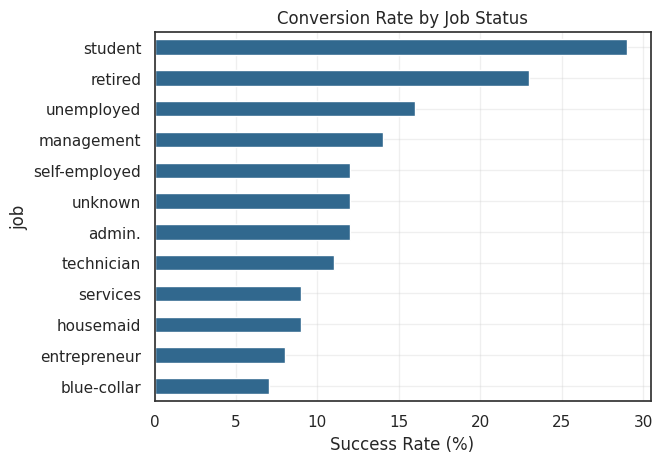

In [224]:
# Plotting the success rates
job_plot_data = job_data.unstack()['yes'].sort_values()
job_plot_data.plot(kind='barh', color=palette[0])
plt.title('Conversion Rate by Job Status')
plt.xlabel('Success Rate (%)')
plt.savefig('graphs/job_success_rate.png', bbox_inches='tight', dpi=300)
plt.show()


The unknown job category has a success rate of 12.0%, which is slightly higher than the overall average of 11.7%.<br>
This suggests that individuals with an unknown job status may have only a fractionally better chance of subscribing to a term deposit compared to the general population. This does not warrant special treatment.

Moreover, there is no order to the job roles in a social context and this feature will be One Hot Encoded.

### Marital Status

In [225]:
df.marital.value_counts(normalize=True).round(2)*100

marital
married     60.0
single      28.0
divorced    12.0
Name: proportion, dtype: float64

In [226]:
# Show distribution of target variable 'y' by marital status
marital_status = df.groupby('marital')['y'].value_counts(normalize=True).round(2)*100
marital_status

marital   y  
divorced  no     88.0
          yes    12.0
married   no     90.0
          yes    10.0
single    no     85.0
          yes    15.0
Name: proportion, dtype: float64

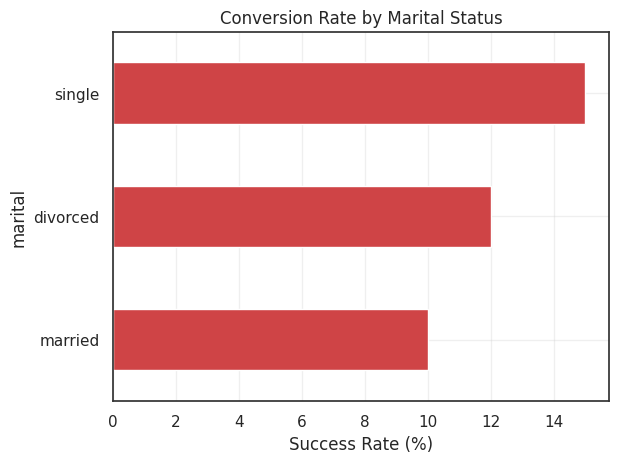

In [227]:
# Plotting the success rates
marital_plot_data = marital_status.unstack()['yes'].sort_values()
marital_plot_data.plot(kind='barh', color=palette[1])
plt.title('Conversion Rate by Marital Status')
plt.xlabel('Success Rate (%)')
plt.savefig('graphs/marital_success_rate.png', bbox_inches='tight', dpi=300)
plt.show()


In reality, there is no "ascending" or "descending" order that matches the marital status categories. Although the order of the 'yes' values suggest it, being divorced isn't a middle stage between single and married! One-hot encoding allows the MLP to treat each status as a unique binary switch.

### Contact Method

The contact feature relates to the type of medium used to *make contact* with the individual.<br>
This is either landline telephone, cellular phone or unknown.

There is no natural order to these types of communication medium, and there is no hidden meaning. Everyone can have a landline or mobile telephone, and back in 2008-2010 either would have been quite common for any class of person to have available. (Today, mobile communication is most prevalent for all, with a landline possibly indicating an older person; this was not true in 2010.)

In [228]:
df.contact.value_counts(normalize=True).round(2)*100

contact
cellular     65.0
unknown      29.0
telephone     6.0
Name: proportion, dtype: float64

In [229]:
# Show distribution of target variable 'y' by contact medium
contact_status = df.groupby('contact')['y'].value_counts(normalize=True).round(2)*100
contact_status

contact    y  
cellular   no     85.0
           yes    15.0
telephone  no     87.0
           yes    13.0
unknown    no     96.0
           yes     4.0
Name: proportion, dtype: float64

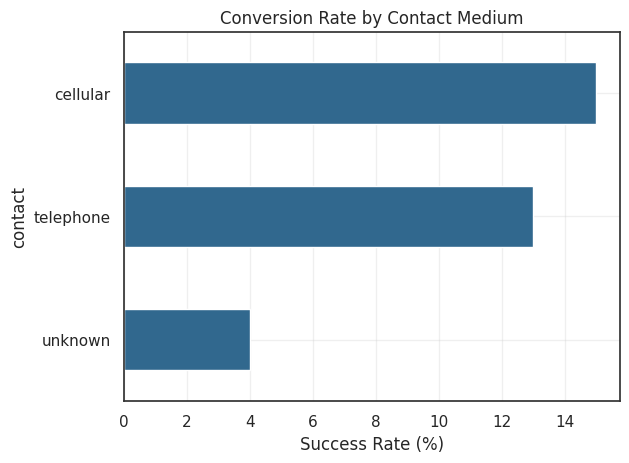

In [230]:
# Plotting the success rates
contact_plot_data = contact_status.unstack()['yes'].sort_values()
contact_plot_data.plot(kind='barh', color=palette[0])
plt.title('Conversion Rate by Contact Medium')
plt.xlabel('Success Rate (%)')
plt.savefig('graphs/contact_success_rate.png', bbox_inches='tight', dpi=300)
plt.show()


Since there is a significant group of unknown values, using one-hot encoding allows the model to learn their unique signature without my needing to guess if they  "should have been" cellular or landline.

### Day (of the month)

This column is unlikely to be useful unless there is a pattern in the data that aligns with a positive result, such as payday patterns.<br>
From the graphs below, this can likely be safely removed from the dataset.

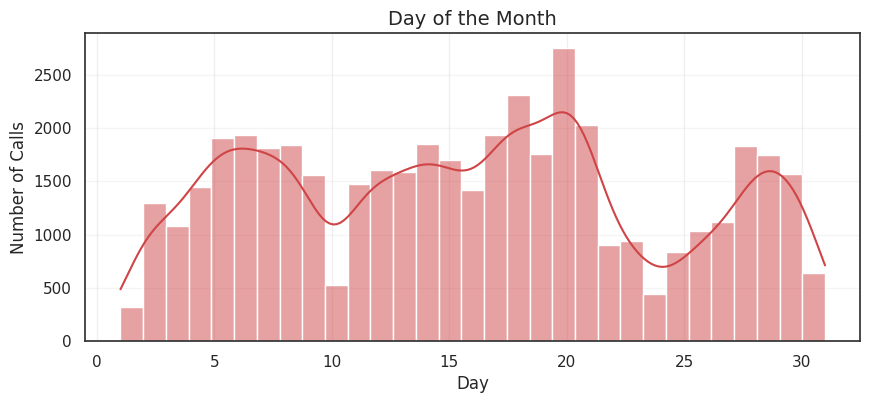

In [231]:
# Plot the distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['day'], bins=31, kde=True, color=palette[1])

plt.title('Day of the Month', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of Calls', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.savefig('graphs/days_of_month_histogram.png', bbox_inches='tight', dpi=300)
plt.show()


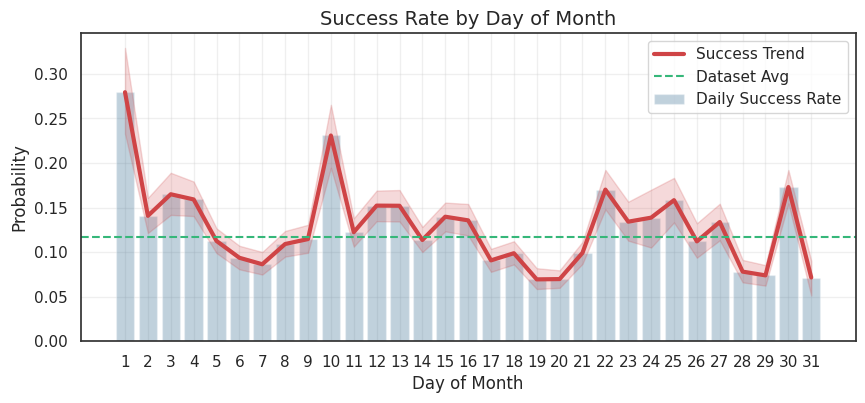

In [232]:
# Ensure y is numeric - create temporary binary column for plotting
df['y_binary'] = df['y'].map({'yes': 1.0, 'no': 0.0}).astype(float)
day_stats = df.groupby('day')['y_binary'].mean()

plt.figure(figsize=(10, 4))

plt.bar(day_stats.index, day_stats.values, color=palette[0], alpha=0.3, label='Daily Success Rate')
sns.lineplot(x='day', y='y_binary', data=df, color=palette[1], linewidth=3, label='Success Trend')
plt.axhline(df['y_binary'].mean(), color=palette[2], linestyle='--', label='Dataset Avg')

plt.title('Success Rate by Day of Month', fontsize=14)
plt.xlabel('Day of Month')
plt.ylabel('Probability')
plt.xticks(range(1, 32))
plt.legend()
plt.savefig('graphs/success_rate_by_day.png', bbox_inches='tight', dpi=300)
plt.show()

# Tidy up the dataframe by removing the temporary binary column
df.drop(columns=['y_binary'], inplace=True)

### Duration

Duration is a problem because as well as being skewed with outliers (as shown in the following chart), it also allows for data leakage into the model.

If a person talks for 30 minutes, they have almost certainly already said "Yes". The longer duration is a result of positive intent, not a cause.<br>
Conversely, if they hang up after a very short time, then they are likely to have said "No".

The bank wants to use the  MLP to decide who to call tomorrow. Since they haven't called yet, they have no "duration" value to give the model.<br> 
The duration only becomes known *after* the decision has already been made, and entered into the target variable 'y'.

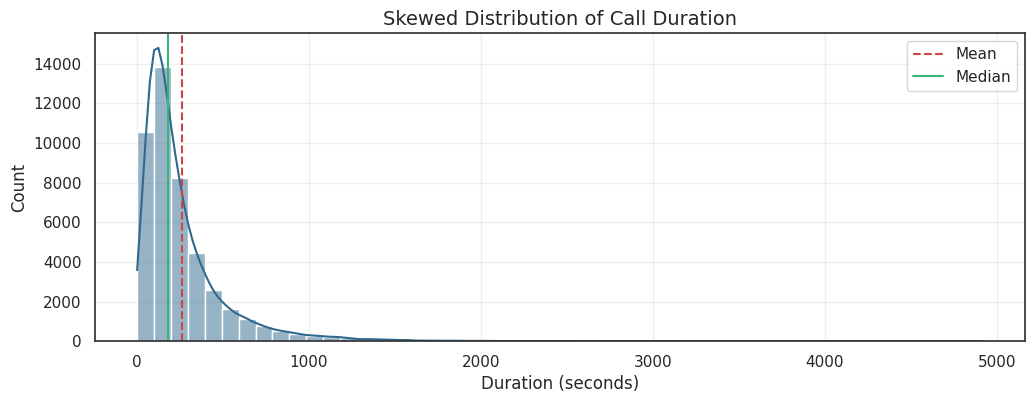

Skew: 3.14


In [233]:
plt.figure(figsize=(12, 4))
sns.histplot(df['duration'], bins=50, kde=True, color=palette[0])

# Add marker lines for mean and median
plt.axvline(df['duration'].mean(), color=palette[1], linestyle='--', label='Mean')
plt.axvline(df['duration'].median(), color=palette[2], linestyle='-', label='Median')

plt.title('Skewed Distribution of Call Duration', fontsize=14)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.legend()
plt.savefig('graphs/duration_skew_histogram.png', bbox_inches='tight', dpi=300)
plt.show()


# Calculate the skew
print(f"Skew: {df['duration'].skew():.2f}")

### Default

This feature shows whether a person has a credit agreement that is 'in default'.<br>
The graph below shows that 98% of the people called are not in default.<br>
It is unlikely that the model will have sufficient examples of 'Yes' to learn from this field; it will be removed.

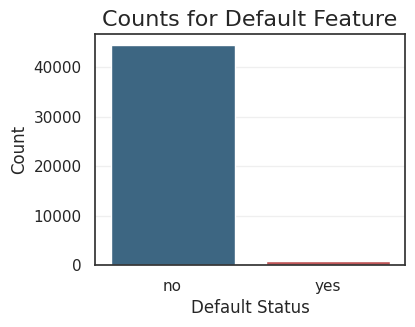

default
no     98.2
yes     1.8
Name: proportion, dtype: float64

In [234]:
plt.figure(figsize=(4,3))
sns.countplot(x='default', data=df, palette=palette)
plt.title("Counts for Default Feature", fontsize=16)
plt.xlabel("Default Status", fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig('graphs/default_count_plot.png', bbox_inches='tight', dpi=300)
plt.show()


(df['default'].value_counts(normalize=True) * 100).round(1)

### Previous Outcome

It makes sense that this feature would likely be a useful indicator for predicting the future outcome of a marketing campaign.<br>
If someone said yes before then they may well be amenable to making further deposits. Conversely, having said yes before may indicate strongly that a person will *not* make a deposit again.

In [235]:
df.poutcome.value_counts(normalize=True).round(2)*100

poutcome
unknown    82.0
failure    11.0
other       4.0
success     3.0
Name: proportion, dtype: float64

In [236]:
poutcome_stats = df.groupby('poutcome')['y'].value_counts(normalize=True).round(2)* 100
poutcome_stats


poutcome  y  
failure   no     87.0
          yes    13.0
other     no     83.0
          yes    17.0
success   yes    65.0
          no     35.0
unknown   no     91.0
          yes     9.0
Name: proportion, dtype: float64

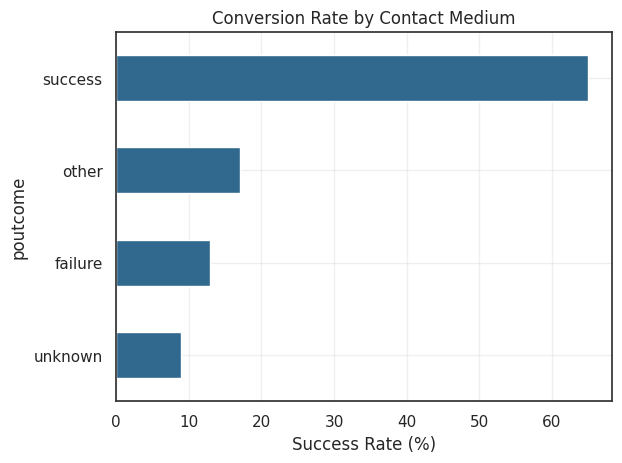

In [237]:
# Plotting the success rates
poutcome_plot_data = poutcome_stats.unstack()['yes'].sort_values()
poutcome_plot_data.plot(kind='barh', color=palette[0])
plt.title('Conversion Rate by Contact Medium')
plt.xlabel('Success Rate (%)')
plt.savefig('graphs/poutcome_success_rate.png', bbox_inches='tight', dpi=300)
plt.show()


There is a massive disparity in the results. This shows that if an individual said "yes" last time, they are overwhelmingly likely to say "yes" again.

One Hot Encoding would allow the MLP to determine for itself that the previous outcome is an excellent indicator. However, as the numebr of unknowns is very high in comparison, there is a strong chance that the MLP might miss these relatively rare signals. This may be made worse as they are distributed across training, validation and test sets.

To assist the MLP in spotting these rare but strong indicators, I will use a map to manually weight these values to reflect their importance:

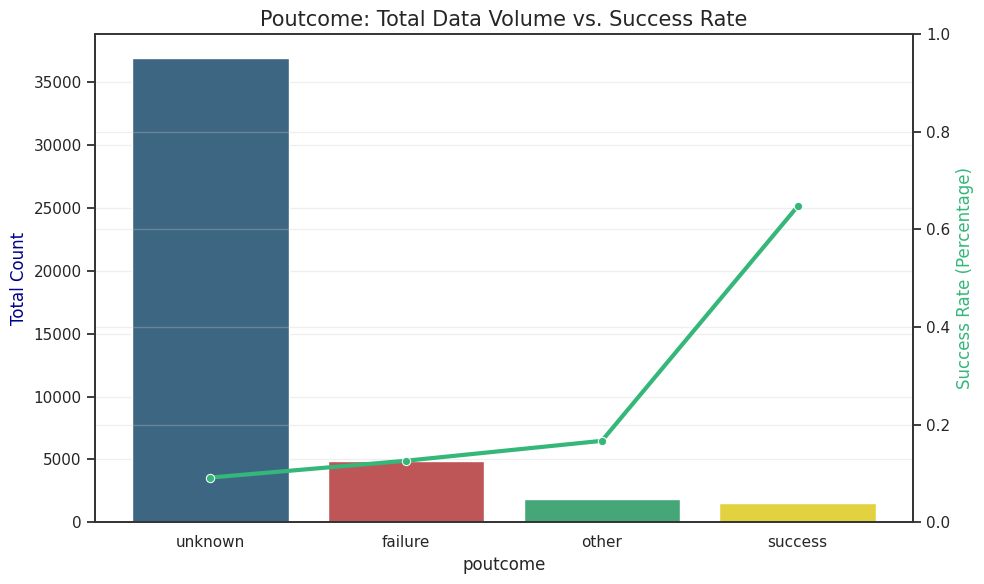

In [238]:

# Group by poutcome to get count and mean (success rate) of y
df['y_bin'] = df['y'].map({'yes': 1, 'no': 0})
poutcome_stats = df.groupby('poutcome')['y_bin'].agg(['count', 'mean']).reset_index()
poutcome_stats.columns = ['poutcome', 'Total Count', 'Success Rate']
poutcome_stats = poutcome_stats.sort_values(by='Total Count', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Create the bar chart for Counts 
sns.barplot(x='poutcome', y='Total Count', data=poutcome_stats, ax=ax1, palette=palette)
ax1.set_ylabel('Total Count', fontsize=12, color='darkblue')
ax1.set_title('Poutcome: Total Data Volume vs. Success Rate', fontsize=15)

# Create second axis for the Success Rate 
ax2 = ax1.twinx()
sns.lineplot(x='poutcome', y='Success Rate', data=poutcome_stats, marker='o', color=palette[2], ax=ax2, linewidth=3)
ax2.set_ylabel('Success Rate (Percentage)', fontsize=12, color=palette[2])
ax2.set_ylim(0, 1) # Set limit to 100%

plt.tight_layout()
plt.savefig('graphs/poutcome_dual_axis.png', bbox_inches='tight', dpi=300)
plt.show()

# Remove the temporary binary column used for calculations
df.drop(columns=['y_bin'], inplace=True)

In [239]:
poutcome_map = {
    'success': 7,
    'other': 2,
    'failure': 0,
    'unknown': 1  
}

# Apply the map to the 'poutcome' column
df['poutcome_numeric'] = df['poutcome'].map(poutcome_map)

# Remove Features

As described above, there are several features that are problematic and will be removed from the dataset.

|Feature	|Action	|Reasoning|
|--|--|--|
|Duration	|Dropped	|Target leakage; duration is not known at the time of prediction.|
|Default	|Dropped	|Near-zero variance; 98% of entries are 'no'.|
| Day | Dropped | Does not appear to add value; no obvious trends.|
|Pdays	|Binned Version Kept|	Re-encoded to handle multi-modal distribution and -1 values.|
|Month| Encoded version kept| Re-encoded as values 1-12|
|Education| Encoded version kept| Re-encoded as values 0-3|
|Poutcome| Encoded version kept| Re-encoded as values 0-7|

In [240]:
# Columns to exclude from the dataset
excluded_features = ['duration','default', 'day', 'pdays', 'month','education','poutcome']
df.drop(columns=excluded_features, inplace=True)

In [241]:
print(df.columns.sort_values())

Index(['age', 'balance', 'campaign', 'contact', 'education_numeric', 'housing',
       'job', 'loan', 'marital', 'month_numeric', 'pdays_binned',
       'poutcome_numeric', 'previous', 'y'],
      dtype='str')


# Encoding Features

I am now going to use what has been learned above to encode and/or scale the remaining features.

In [242]:
df.columns

Index(['age', 'job', 'marital', 'balance', 'housing', 'loan', 'contact',
       'campaign', 'previous', 'y', 'pdays_binned', 'month_numeric',
       'education_numeric', 'poutcome_numeric'],
      dtype='str')

In [243]:
df.shape[1]

14

In [244]:
binary_cols = ['housing', 'loan', 'y']
outlier_numeric_cols = ['age', 'balance', 'campaign', 'previous']
normal_numeric_cols = [ 'pdays_binned', 'month_numeric','education_numeric', 'poutcome_numeric']
categorical_cols = ['job', 'marital', 'contact']

In [245]:
len(binary_cols) + len(outlier_numeric_cols) + len(normal_numeric_cols) + len(categorical_cols)

14

## Encoding Binary Columns

In [246]:
# Encode the Binary Features
for col in binary_cols:
    # Convert yes/no values to float versions
    df[col] = df[col].map({'yes': 1.0, 'no': 0.0}).astype(float)

## Min-Max Normalisation Function


$ x_scaled = \frac{x - min(x)}{max(x)-min(x)}$



In [247]:
def min_max_column(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val)

# Apply to the 
for col in normal_numeric_cols:
    df[col] = min_max_column(df[col])

In [248]:
df.sample(5)[normal_numeric_cols]

,pdays_binned,month_numeric,education_numeric,poutcome_numeric
14775,0.0,0.545455,0.333333,0.142857
22004,0.0,0.636364,0.333333,0.142857
24461,0.5,0.909091,0.333333,0.000000
13740,0.0,0.545455,0.333333,0.142857
25211,0.0,0.909091,0.333333,0.142857


## Encoding Columns with Outliers

To encode the features with outliers, a Standardised Z-Score Scaler will be used. <br>
This centres the values around 0, which will be the mean. The standard deviation is used calculate the spread of values.

$x_{scaled} = \frac{x - \mu}{\sigma}$

In [249]:

def zscore_column(data):
    mu = np.mean(data)
    sigma = np.std(data)
    return (data - mu) / sigma

# Encode the outlier columns using standardization
for col in outlier_numeric_cols:
    df[col] = zscore_column(df[col])

In [250]:
df.sample(5)[outlier_numeric_cols]

,age,balance,campaign,previous
16387,-0.559037,-0.443807,0.399020,-0.251940
30282,-0.841558,-0.398154,-0.569351,-0.251940
31487,0.382703,-0.317359,0.399020,1.484611
2499,0.194355,-0.655319,-0.569351,-0.251940
34849,-0.935732,0.499134,-0.246560,-0.251940


In [251]:
df.shape[1]

14

## Categorical Features - One Hot Encoding

In [252]:
# One Hot Encode the categorical features, resulting in True/False values for each category
df = pd.get_dummies(df, columns=categorical_cols, dtype=float)

df.sample(5)

,age,balance,housing,loan,campaign,previous,y,pdays_binned,month_numeric,education_numeric,...,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown
41285,-0.559037,-0.121611,1.0,0.0,-0.569351,1.050473,0.0,0.5,0.636364,1.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
20131,-0.464863,-0.444463,0.0,0.0,0.399020,-0.251940,1.0,0.0,0.636364,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
22468,1.041921,-0.447419,0.0,0.0,-0.246560,-0.251940,0.0,0.0,0.636364,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
666,-0.559037,-0.398811,1.0,0.0,-0.246560,-0.251940,0.0,0.0,0.363636,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
23215,-0.276515,-0.362683,0.0,0.0,0.399020,-0.251940,0.0,0.0,0.636364,0.333333,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [253]:
df.columns

Index(['age', 'balance', 'housing', 'loan', 'campaign', 'previous', 'y',
       'pdays_binned', 'month_numeric', 'education_numeric',
       'poutcome_numeric', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown'],
      dtype='str')

In [254]:
df.shape

(45211, 29)

## Check Correlation

In [255]:
# Check correlations with the target variable 'y' to see which features are most strongly associated with the outcome
correlations = df.corr()['y'].sort_values(ascending=False)
print(correlations.head(10))

y                    1.000000
poutcome_numeric     0.289184
contact_cellular     0.135873
pdays_binned         0.128679
previous             0.093236
job_retired          0.079245
job_student          0.076897
education_numeric    0.072493
marital_single       0.063526
balance              0.052838
Name: y, dtype: float64


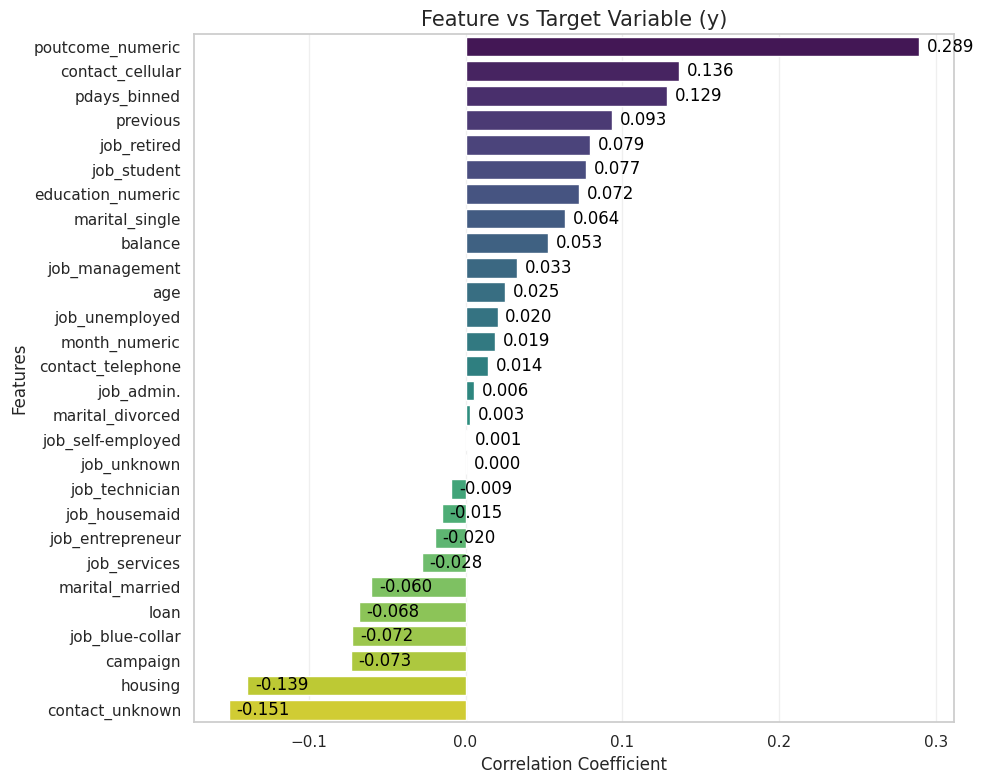

In [256]:
corr_to_plot = correlations.drop('y').sort_values(ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=corr_to_plot.values, y=corr_to_plot.index, palette="viridis")
plt.title('Feature vs Target Variable (y)', fontsize=15)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Add value labels to the end of each bar
for i, v in enumerate(corr_to_plot.values):
    ax.text(v + 0.005, i, f'{v:.3f}', color='black', va='center')

plt.tight_layout()
plt.savefig('graphs/feature_correlations.png', bbox_inches='tight', dpi=300)
plt.show()


Strongest Positive: poutcome_numeric (0.289) and contact_cellular (0.136).

Demographics: job_retired, job_student, and marital_single are all positively correlated with success. This confirms that specific life stages are more likely to say "yes". Students, for example, are likely planning for their future and trying to make savings, while the retired likely have spare cash to invest.

Weak correlation: Balance (0.053) is lower than expected. It is not the primary driver for a "yes" in this campaign.

In [257]:
df.columns

Index(['age', 'balance', 'housing', 'loan', 'campaign', 'previous', 'y',
       'pdays_binned', 'month_numeric', 'education_numeric',
       'poutcome_numeric', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown'],
      dtype='str')

## Save the Dataframe
Write out the dataframe to files

In [258]:
# Create filenames, one timestamped, one 'latest'
filepath = "."

filename = f'{filepath}/bank_full_scaled_{now_date_timestamp}.csv'
latest_filename = f'{filepath}/bank_full_scaled_latest.csv'

# Write out CSV files
df.to_csv(filename, index=False)
df.to_csv(latest_filename, index=False)